<a href="https://colab.research.google.com/github/NoaTal1996/Backbone-Graph/blob/main/src/Topic_Clustring_and_NER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instalations and Imports

In [62]:
try:
    # Running inside Google Colab → use !pip
    import google.colab
    in_google_colab = True
    print("Running in Colab → installing packages...")
    !pip install -q bertopic
    !pip install -q tweet-preprocessor
    !pip install -q spacy-entity-linker
    !pip install -q emoji
    !pip install sentence-transformers scikit-learn
    !pip install "transformers>=4.40.0" sentencepiece accelerate torch
except ImportError:
    # Not running in Colab
    in_google_colab = False
    pass

In [63]:
import pandas as pd
import pyarrow  # ensures pandas can read/write parquet
import matplotlib.pyplot as plt

import re
import emoji

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

import spacy

from tqdm.auto import tqdm
from IPython.display import display

# Loading and Exporting
[Labeled Datasets for Research on Information Operations](https://zenodo.org/records/14189193)

## Load Data

In [64]:
dataset_name = "Labeled_Datasets/Ecuador"  # folder path
file_name = f"Ecuador_part_all.gzip.parquet"  # file name

# if run local: put data in "../data/<dataset_name>/<file_name>"
# Recommended: working directory is: "Backbone-Graph/src"

In [65]:
from pathlib import Path

# Google Colab
if in_google_colab:
    from google.colab import drive
    drive.mount('/content/drive')
    dataset_path = Path("/content/drive/Shareddrives/KeyBoostAuthor") / dataset_name / file_name
    print("Running inside Colab. Loading from Google Drive...")

# Cluster\Local
else:
    # Recommended: working directory is: "Backbone-Graph/src"
    dataset_path = Path("../data") / dataset_name / file_name
    print(f"Running on local/cluster.\nLoading data from: {dataset_path}")


# Load the parquet file
df = pd.read_parquet(dataset_path)

# for testing
df = df.sample(n=100, random_state=42).copy()

Running on local/cluster.
Loading data from: ../data/Labeled_Datasets/Ecuador/Ecuador_part_all.gzip.parquet


## Output Path


In [66]:
from datetime import datetime
today = datetime.now().strftime("%Y_%m_%d")


dataset_path = Path(dataset_path)


if in_google_colab:
  output_folder_path = (dataset_path.parents[2] / "Labeled_Dataset_with_Topic_NER" / dataset_path.parent.name / dataset_path.name)
else:
  # working directory is: Backbone-Graph/src
  file_name_no_suffixes = file_name.split(".")[0]
  output_folder_path = Path("../results") / dataset_name / file_name_no_suffixes / today
  # Example: ""../results/Labeled_Datasets/Ecuador/Ecuador_part_4/2025_11_27"



output_folder_path.mkdir(parents=True, exist_ok=True) # Createst the output directory if needed

print(f"output_folder_path = {output_folder_path}")

output_folder_path = ../results/Labeled_Datasets/Ecuador/Ecuador_part_all/2025_12_23


In [67]:
df.head()

,postid,post_text,application_name,post_language,in_reply_to_postid,in_reply_to_accountid,post_time,accountid,account_profile_description,follower_count,following_count,account_creation_date,is_repost,reposted_accountid,reposted_postid,hashtags,urls,account_mentions,is_control
769276,ca06f1aebbcaf871492fefb92090d0e2e3885dc5be,https://9b6e9a57746724dd79b953b2f0022721b53c58ff26 Con @81442ccfa9f28b934ccf2bb3fb28ebc31af98d0c7d los Jóvenes tienen un futuro lleno de oportunidades🙋‍♀️🙋🏻‍♂️ vamos @2fcc776a3b97d7bc33b3d72acfdf9e9a9f7d55fa3e #MeadeConLosJovenes\n #AvanzarConLosJovenes,15592fcc82d5064a8f4a3b89774e6cd0bbd2118aa0,es,None,None,2018-06-06 23:58:11,b28a77b846f3964b7ef4a4134d662fb91726fb0f68,2 de octubre no se olvida. De sandía es mi corazón.,659,629,2011-02-27,True,71a93e64fa7516b0e2a537a0f7a48c7bd6be6c5ac0,b5640970c915dcd5022a1612344b9a4d0bc986eefe,"[MeadeConLosJovenes, AvanzarConLosJovenes]",[https://9b6e9a57746724dd79b953b2f0022721b53c58ff26],"[71a93e64fa7516b0e2a537a0f7a48c7bd6be6c5ac0, 81442ccfa9f28b934ccf2bb3fb28ebc31af98d0c7d, 2fcc776a3b97d7bc33b3d72acfdf9e9a9f7d55fa3e]",True
860817,a90d3a1fd06ad7f5ad561d59d54c6602b653e77205,"#VIDEO Chávez: Nuestro camino no es el odio ni la guerra, es el del triunfo y la victoria... La paz con dignidad @25b3f1d6608019c52d8b94a379f8e68619298017fe https://486eba79e2b3d1f820cc0a91920ef1d2ba6c921c82",62010408238d4a0f958ec97eec3db0a4f69bcd0d11,es,None,None,2018-08-05 23:48:18,b0afd37c06c5e6cfe04f6c50d5c6d3970a56db8a8b,"Joven Chavista y Revolucionario, Soñador de una Patria Libre y Soberana.\n#ModoActivo por mi Patria.... 💛💙❤️¡Venceremos!",2906,1088,2017-06-20,True,65652740c7b667c0721a0da49b1b1b9622f92debc3,9c665366e213e2395fc737ae93fd442538882edd61,[VIDEO],[https://486eba79e2b3d1f820cc0a91920ef1d2ba6c921c82],"[65652740c7b667c0721a0da49b1b1b9622f92debc3, 25b3f1d6608019c52d8b94a379f8e68619298017fe]",True
167907,fe6d263080973f8a0473f539bf970935b5d6b45e18,Infidelidad masculina luego del consumo de alcohol podría tener una explicación biológica https://d7a745c4cdf26c5daf1d9379ac376329a55710e137 #EsElColmo,e3415c9cb59e8c2e081aab325f8e78eeef650d5b4b,es,None,None,2014-04-14 17:59:00,71cc57155d061d447c2c65756c7dfd6873e403a097,🍃🧚‍♀️🧜‍♀️👑,3618,2055,2009-12-22,False,None,None,[EsElColmo],[https://d7a745c4cdf26c5daf1d9379ac376329a55710e137],[],False
395024,d3a1a0c4579b70c4bd1bb82dde38200ddaf5a953ef,"Buenas tardes! Previo a la reinstalación de Audiencia Pública de Escrutinios, Pleno del @8cd86abc87eb6d2e2c12139c3490b2756d03092f38 mantiene sesión ordinaria https://0258a6a9322da6f60c8ee98203fee669a7dddbf6c8",15592fcc82d5064a8f4a3b89774e6cd0bbd2118aa0,es,None,None,2017-02-28 21:56:48,2326bf7cce531ef18954c90de5b6df39f1cb263845,Delegación Provincial Electoral de Carchi ¡La democracia está en ti!,3852,154,2012-09-03,True,b23e5d244b7f7f67d27dbea12131fd6ddc078b33b0,84494d082eab2d0c2951414021df407efdbee2bbd0,[],[https://0258a6a9322da6f60c8ee98203fee669a7dddbf6c8],"[b23e5d244b7f7f67d27dbea12131fd6ddc078b33b0, 8cd86abc87eb6d2e2c12139c3490b2756d03092f38]",True
710506,c905d6b1b0eaa0d7f8ae2ebf2ca4f1594f5920d66c,"#3bb1a651896e919384f4fd7c1a9464e09f8f41f6fa | Fiscal #CarlosBacaM compareció ante la Comisión de Fiscalización de la Asamblea, dentro del proceso de juicio político en su contra. Cuestionó que se solicite a un juicio por hechos que no tienen vinculación con un presunto incumplimiento de sus funciones▼ https://a574382865fc9d34ccb1613ae85e2f510fc89b45c7",072f1b013621f1b0d9753c98d97f5a0a97a8b68303,es,None,None,2018-04-12 02:21:08,4326dbcdf4b8d52e4fa2104d60872b008082ea95a9,"Periodista (Máster y otros) y trotamundos. Para los trolls: viví en La Paz, Santiago de Chile, Buenos Aires, París y Milán. En la foto estoy en Guillin, China.",14527,1014,2012-11-26,True,3bb1a651896e919384f4fd7c1a9464e09f8f41f6fa,63f107c0d79bbd255089e89f93e18f2667de2d9a49,"[TelediarioEC, CarlosBacaM]",[https://a574382865fc9d34ccb1613ae85e2f510fc89b45c7],[3bb1a651896e919384f4fd7c1a9464e09f8f41f6fa],True


# Dataset Statistics

In [68]:
total_posts = len(df)
hashtag_posts = df[df['hashtags'].notna() & (df['hashtags'].str.len() > 0)]
mention_posts = df[df['account_mentions'].notna() & (df['account_mentions'].str.len() > 0)]
url_posts = df[df['urls'].notna() & (df['urls'].str.len() > 0)]
start_date = df["post_time"].min().strftime("%Y-%m")
end_date = df["post_time"].max().strftime("%Y-%m")

stats_text = [
    f"Posts time range: {start_date} → {end_date}",
    "",
    f"{'df shape:':<40} {df.shape}",
    f"{'df posts with hashtags # shape:':<40} {hashtag_posts.shape}  ({len(hashtag_posts)/total_posts*100:.2f}%)",
    f"{'df posts with account_mentions @ shape:':<40} {mention_posts.shape}  ({len(mention_posts)/total_posts*100:.2f}%)",
    f"{'df posts with urls shape:':<40} {url_posts.shape}  ({len(url_posts)/total_posts*100:.2f}%)",
]

# print to console
print("\n".join(stats_text))

# save to file
if output_folder_path:
    output_folder_path = Path(output_folder_path)
    report_path = output_folder_path / "dataset_summary.txt"
    report_path.write_text("\n".join(stats_text), encoding="utf-8")

print()
print()

print(f"{'**collum name**':<30} **value type**")
for col in df.columns:
    # dtype_str = str(df[col].dtype)  # Convert dtype to string
    # get a sample non-null value if exists
    sample_val = df[col].dropna().iloc[0] if df[col].notna().any() else None
    print(f"{col:<30} | {type(sample_val).__name__}")


print()
print()
print(df['post_language'].value_counts())

Posts time range: 2011-09 → 2019-05

df shape:                                (100, 19)
df posts with hashtags # shape:          (42, 19)  (42.00%)
df posts with account_mentions @ shape:  (89, 19)  (89.00%)
df posts with urls shape:                (45, 19)  (45.00%)


**collum name**                **value type**
postid                         | str
post_text                      | str
application_name               | str
post_language                  | str
in_reply_to_postid             | str
in_reply_to_accountid          | str
post_time                      | Timestamp
accountid                      | str
account_profile_description    | str
follower_count                 | int64
following_count                | int64
account_creation_date          | date
is_repost                      | bool
reposted_accountid             | str
reposted_postid                | str
hashtags                       | ndarray
urls                           | ndarray
account_mentions               | nd

# Clean Text

## Clean text With Entities

In [69]:
def clean_url(url_match):

    url = url_match.group(0)

    # 1. Remove protocol (http:// or https://)
    url = re.sub(r"https?://", "", url)
    url = re.sub(r"www\.", "", url)

    # 2. Remove query parameters (?x=1)
    url = url.split("?")[0]

    # 3. Split into components by "/"
    parts = url.split("/")

    # Domain (first part)
    domain = parts[0].replace(".", "_")  # twitter.com → twitter_com

    # First section (second part of the URL)
    if len(parts) > 1 and parts[1].strip() != "":
        section = parts[1].replace(".", "_")
        token = f" URL_{domain}_{section} "
    else:
        token = f" URL_{domain} "

    return token

In [70]:
def clean_text(text: str) -> str:

    # lowercase
    text = str(text).lower()

    # URLs → domian + first section
    text = re.sub(r"(https?://\S+|www\.\S+)", clean_url, text)

    # Hashtags → HASHTAG_xxx
    text = re.sub(r"#(\w+)", r" HASHTAG_\1 ", text)

    # Mentions → MENTION_xxx
    text = re.sub(r"@(\w+)", r" MENTION_\1 ", text)

    # emoji → EMOJI_xxx
    text = emoji.demojize(text, delimiters=(" EMOJI_", " "))

    # Collapse spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [71]:
df["clean_text_with_entities"] = df["post_text"].apply(clean_text)

## Remove Text Without Enttities

In [72]:
import re
import pandas as pd

URL_RE = re.compile(r"(https?://\S+|www\.\S+)", flags=re.IGNORECASE)
MENTION_RE = re.compile(r"@\w+")
HASHTAG_RE = re.compile(r"#(\w+)")
WHITESPACE_RE = re.compile(r"\s+")

def clean_enteties(text: str) -> str:
    """
    Lightly clean a social-media post while keeping it natural
    for machine translation.

    Operations:
    - Replace URLs with <URL>
    - Replace @username with <USER>
    - Turn #hashtag into 'hashtag' (drop the #)
    - Collapse repeated whitespace
    """
    if not isinstance(text, str):
        text = str(text)

    # lowercase
    text = str(text).lower()

    # 1. Normalize URLs
    text = URL_RE.sub("<URL>", text)

    # 2. Normalize mentions
    text = MENTION_RE.sub("<USER>", text)

    # 3. Normalize hashtags: "#Ecuador2025" -> "Ecuador2025"
    text = HASHTAG_RE.sub(r"\1", text)

    # 4. Collapse whitespace
    text = WHITESPACE_RE.sub(" ", text).strip()

    return text

In [73]:
df["clean_text_without_enteties"] = df["post_text"].astype(str).apply(clean_enteties)

In [74]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 2000)

df[["post_text", "clean_text_without_enteties"]].sample(n=20)

,post_text,clean_text_without_enteties
1112595,"El Gobierno Nacional presentó una #Proforma2019 técnica, equilibrada y responsable. El debate debe llevarnos a proponer m…","el gobierno nacional presentó una proforma2019 técnica, equilibrada y responsable. el debate debe llevarnos a proponer m…"
544268,"Por primera vez, la violencia machista ha pasado a ser cuestión de Estado. Buscad ayuda. #diacontralaviolenciadegenero https://60383d30672dcbafb8fdd82672513e89bb39ed23e6","por primera vez, la violencia machista ha pasado a ser cuestión de estado. buscad ayuda. diacontralaviolenciadegenero <URL>"
589878,CASO SILVA:\n1. Indisciplina antes de la final vs CSE.\n2. Se nacionaliza RAPIDITO.\n3. Hoy suena para el equipo rival de la pasada final. \nPREGUNTAS:\n1. ¿Quién ayudó en el trámite de nacionalidad?\n2. ¿Sería ética su llegada al CSE?\n3. ¿Qué opina la gente de Delfín?,caso silva: 1. indisciplina antes de la final vs cse. 2. se nacionaliza rapidito. 3. hoy suena para el equipo rival de la pasada final. preguntas: 1. ¿quién ayudó en el trámite de nacionalidad? 2. ¿sería ética su llegada al cse? 3. ¿qué opina la gente de delfín?
652078,@2183492c0e7f6787e3819d3082f62d99fcade8d3d6 😂😂😂 Sporcaccione... 😂😂😂,<USER> 😂😂😂 sporcaccione... 😂😂😂
1442313,"""Nosotros siempre hemos manifestado que hay que regresar los ojos al campo, porque sin duda alguna ha estado olvidado,…","""nosotros siempre hemos manifestado que hay que regresar los ojos al campo, porque sin duda alguna ha estado olvidado,…"
728492,"#Impacto148 | Se decomisaron 1.888 kg de clorhidrato de cocaína. Seis personas detenidas, cinco vehículos aprehendidos…","impacto148 | se decomisaron 1.888 kg de clorhidrato de cocaína. seis personas detenidas, cinco vehículos aprehendidos…"
145660,Ivetãoo no domingão,ivetãoo no domingão
189308,"""@bfed5edb5293d0a19ba70c8329294887fa263ac361: Propietarios exigen derecho al trabajo a la alcaldía de @ea659736e9cfcaaa784ba2c3671d476e26fd86adc4 https://ab5c3efd419154142791f1dbe8aee8d13d9d13de25"" @4f118f396497df4ad5c2d03c63949d7869b6f1eaf8 @703f0fb99d8387c39476f394648723263241dc27b3","""<USER>: propietarios exigen derecho al trabajo a la alcaldía de <USER> <URL> <USER> <USER>"
360950,#MoflevsRafael la mofletuda lo caga al panzón. Punto para la mofletuda,moflevsrafael la mofletuda lo caga al panzón. punto para la mofletuda
992586,Incredible sunset in Hawaii https://4a1bc5bf34a6a2c1308479513c846bde620050fb4a,incredible sunset in hawaii <URL>


# Translation to English

In [75]:
# map post_language codes to NLLB-200 language codes
# https://dl-translate.readthedocs.io/en/latest/available_languages/

def map_to_nllb_code(lang_code: str) -> str:
    """
    Map your dataset's post_language codes to NLLB-200 language codes.
    If not in mup return the same language code.
    Args:
        lang_code (str): Post language code.
    Returns:
        str: NLLB-200 language code.
    """
    nllb_mapping = {
    # Europe
    "en": "eng_Latn",   # English
    "es": "spa_Latn",   # Spanish
    "pt": "por_Latn",   # Portuguese
    "fr": "fra_Latn",   # French
    "de": "deu_Latn",   # German
    "it": "ita_Latn",   # Italian
    "nl": "nld_Latn",   # Dutch
    "ru": "rus_Cyrl",   # Russian
    "pl": "pol_Latn",   # Polish
    "sv": "swe_Latn",   # Swedish
    "ca": "cat_Latn",    # Catalan
    "cy": "cym_Latn",    # Welsh
    "et": "est_Latn",    # Estonian

    # Middle East
    "ar": "arb_Arab",   # Arabic (MSA)
    "he": "heb_Hebr",   # Hebrew
    "tr": "tur_Latn",   # Turkish
    "fa": "pes_Arab",   # Persian/Farsi

    # South Asia
    "hi": "hin_Deva",   # Hindi
    "ur": "urd_Arab",   # Urdu
    "bn": "ben_Beng",   # Bengali

    # East Asia
    "zh": "zho_Hans",   # Chinese Simplified
    "ja": "jpn_Jpan",   # Japanese
    "ko": "kor_Hang",   # Korean

    # Southeast Asia
    "vi": "vie_Latn",   # Vietnamese
    "id": "ind_Latn",   # Indonesian (modern code)
    "in": "ind_Latn",   # Indonesian (legacy ISO code)
    "tl": "tgl_Latn",   # Tagalog (Philippines)

    # Africa
    "sw": "swh_Latn",   # Swahili

    # Americas
    "qu": "quy_Latn",   # Quechua (Ayacucho)
}


    if lang_code in nllb_mapping:
        return nllb_mapping[lang_code]
    else:
        return lang_code

In [76]:
df["post_language"] = df["post_language"].apply(map_to_nllb_code)

In [77]:
# load models

import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline

MODEL_NAME = "facebook/nllb-200-distilled-600M"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)
translation_pipeline = pipeline("translation", model=model, tokenizer=tokenizer, device=device, max_length=1000, batch_size=16)

Using device: cuda


Device set to use cuda


In [78]:
from tqdm.auto import tqdm


def transformers_translator(
    df: pd.DataFrame,
    translation_pipe,
    text_col: str = "clean_text_with_entities",
    lang_col: str = "post_language",
    out_col: str = "translated_post",
    target_lang: str = "eng_Latn",
    pivot_lang: str = "spa_Latn",
    backtranslate_same_lang: bool = True,
) -> pd.DataFrame:
    """
    Translate df[text_col] → target_lang using NLLB pipeline.

    If src_lang == target_lang and backtranslate_same_lang=True,
    perform back-translation: target_lang → pivot_lang → target_lang.

    Args:
        df (pd.DataFrame):
            Input DataFrame containing text and language labels.
        translation_pipe (transformers.pipeline):
            Pre-loaded translation pipeline (e.g., NLLB-200).
        text_col (str):
            Column containing original text.
        lang_col (str):
            Column containing language codes matching the pipeline
            (e.g., "spa_Latn", "eng_Latn").
        out_col (str):
            Column name for the translated output.
        target_lang (str):
            Target language code (default: "eng_Latn").
        pivot_lang (str):
            Pivot language code for back-translation (default: "spa_Latn").
        backtranslate_same_lang (bool):
            If True, back-translate rows where src_lang == target_lang.

    Returns:
        pd.DataFrame:
            A DataFrame with the same index as df and one column (out_col).
    """

    result_df = pd.DataFrame(index=df.index)
    result_df[out_col] = None

    # Iterate per language with progress bar
    for src_lang, group in tqdm(df.groupby(lang_col), desc="Translating by language"):

        # Build a list[str]
        texts = group[text_col].astype(str).tolist()

        # Keep the original indexes so we can assign back later
        indexes = group.index.to_list()

        translated = []  # empty means "no translation done"

        # Case 1: normal translation src_lang -> target_lang
        if src_lang != target_lang:
            print(f"{len(texts)} posts: {src_lang} → {target_lang}")
            outputs = translation_pipe(
                texts,
                src_lang=src_lang,
                tgt_lang=target_lang,
            )
            translated = [o["translation_text"] for o in outputs]

        # Case 2: back-translation target_lang -> pivot_lang -> target_lang
        if (src_lang == target_lang) and backtranslate_same_lang:
            print(f"{len(texts)} posts: {target_lang} → {pivot_lang} → {target_lang}")
            pivot_outputs = translation_pipe(
                texts,
                src_lang=target_lang,
                tgt_lang=pivot_lang,
            )
            pivot_texts = [o["translation_text"] for o in pivot_outputs]

            back_outputs = translation_pipe(
                pivot_texts,
                src_lang=pivot_lang,
                tgt_lang=target_lang,
            )
            translated = [o["translation_text"] for o in back_outputs]

        if translated:
            result_df.loc[indexes, out_col] = translated

    return result_df

In [79]:
print(f"df shape: {df.shape}")
translated_df = transformers_translator(df, translation_pipeline)
df = df.drop(columns=["translated_post"], errors="ignore") # Drop the old column if exist
df = df.join(translated_df)

df shape: (100, 21)


Translating by language:   0%|          | 0/7 [00:00<?, ?it/s]

1 posts: cat_Latn → eng_Latn
11 posts: eng_Latn → spa_Latn → eng_Latn
1 posts: ita_Latn → eng_Latn
1 posts: jpn_Jpan → eng_Latn
2 posts: por_Latn → eng_Latn
78 posts: spa_Latn → eng_Latn
5 posts: und → eng_Latn


In [80]:
pd.set_option("display.width", 3000)
pd.set_option("display.max_colwidth", 1500)

df.sample(10)[["clean_text_without_enteties", "translated_post"]]

,clean_text_without_enteties,translated_post
582781,"dentro de dos semanas debatiremos con otros compañeros ctos sobre el perfil del profesional it: lo que queremos, deseamos y necesitamos. <USER> <URL>","Within two weeks we will discuss with other colleagues the profile of the professional it: what we want, want and need. MENTION_30104b006f6227a09b7be75d47c27e42abfda3796a URL_36f199eeada09bb515f463bbd6b1ffa844471f71ca"
976423,director ejecutivo <USER> mantiene reunión con los directores nacionales y provinciales sobre planificación del transpo…,Executive Director MENTION_e0ba95561ebced53228ad2f75c108cb82e2d2f9df2 holds a meeting with the national and provincial directors on transport planning...
621080,"<USER> por una mejor provincia, trabajo y seriedad trabajocomprobado","MENTION_c7e806bfd55c18a2e2a811ce7702faae5cbb9d488f for a better province, work and seriousness"
128970,"...los bomberos de anzoategui y pdvsa no le dieron chance a la oposición, frustraron su ataque, el bien siempre prevalece _o/","...the firefighters of anzoategui and pdvsa didn't give the opposition a chance, they thwarted their attack, good always prevails"
882075,"compartimos el mensaje del presidente <USER> moreno al país, sobre las decisiones económicas adoptadas por el gobierno…",We share President MENTION_aae2514dd2b49b2e9005f27a9b7c88b4368e7b0c2d message to the country about the economic decisions taken by the government...
636617,"crnlluna, director de la escuela superior de policía, da la bienvenida a los cadetes y señala que las satisfacciones no vienen de las cosas materiales sino del servicio que se entrega a la ciudadanía. bienestarpolicial <URL>","HASHTAG_crnlluna, Director of the Higher Police School, welcomes the cadets and points out that satisfaction comes not from material things but from the service rendered to citizenship."
1085439,"“desde nuestra visión, la verdadera inclusión se debe traducir en atención inmediata, registro, y, sobre todo, en apoyo…","from our point of view, true inclusion must be translated into immediate attention, registration, and, above all, support..."
728492,"impacto148 | se decomisaron 1.888 kg de clorhidrato de cocaína. seis personas detenidas, cinco vehículos aprehendidos…","1,888 kilograms of cocaine hydrochloride were seized, six people arrested, five vehicles seized..."
1001763,"“¿quién es el que vence al mundo, sino el que cree que jesús es el hijo de dios?”. -1 juan 5.5",Who is he that overcomes the world but he who believes that Jesus is the Son of God?
402295,".<USER> ""la misión de <USER> es generar más empleo, más vivienda, más obras para los ecuatorianos.fortalecer los logros obtenidos"" <URL>",". MENTION_c09b5b44e08e1dee0355a17be46f8d9dec3dee0d71 ""The mission of MENTION_aae2514dd2b49b2e9005f27a9b7c88b4368e7b0c2d is to generate more jobs, more housing, more jobs for Ecuadorians.Strengthen the achievements achieved"" URL_ee0ec81bd276f2a7e52de267a91f3b7911d68d5fc1"


# Remove Engllish Stopwords

In [81]:
from nltk.corpus import stopwords
import nltk

In [82]:
nltk.download('stopwords')

EXTRA_STOPWORDS = [
    'he', 'she', 'they', 'you', 'i', 'we', 'im', 'hes', 'shes', 'its', 'rt', 'amp', 're',
    'theyre', 'dont', 'doesnt', 'would', 'could', 'like', 'know', 'say', 'said', 'one',
    'look', 'looks', 'think', 'oh', 'yeah', 'guy', 'gonna', 'thing', 'someone', 'people',
    'get', 'got', 'thats', 'just', 'really', 'even', 'still', 'want', 'need', 'needs',
    'me', 'to', 'you', 'the', 'that', 'be', 'my', 'get', 'in', 'and',
     'rt', 'the', 'https', 'to', 'my', 'it', 'on', 'you', 'of', 'for', 'https', 'http', 'RT'
]
all_stopwords_english = set(stopwords.words('english') + EXTRA_STOPWORDS)

def remove_stopwords(text):
    if not text:
        return text
    return " ".join([w for w in text.lower().split() if w not in all_stopwords_english])


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/amitner/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [83]:
df["clean_text_with_entities"] = df["clean_text_with_entities"].apply(remove_stopwords)
df["clean_text_without_enteties"] = df["clean_text_without_enteties"].apply(remove_stopwords)
df["translated_post"] = df["translated_post"].apply(remove_stopwords)

In [84]:
df[["post_text", "clean_text_with_entities"]].head(20)

,post_text,clean_text_with_entities
769276,https://9b6e9a57746724dd79b953b2f0022721b53c58ff26 Con @81442ccfa9f28b934ccf2bb3fb28ebc31af98d0c7d los Jóvenes tienen un futuro lleno de oportunidades🙋‍♀️🙋🏻‍♂️ vamos @2fcc776a3b97d7bc33b3d72acfdf9e9a9f7d55fa3e #MeadeConLosJovenes\n #AvanzarConLosJovenes,url_9b6e9a57746724dd79b953b2f0022721b53c58ff26 con mention_81442ccfa9f28b934ccf2bb3fb28ebc31af98d0c7d los jóvenes tienen un futuro lleno de oportunidades emoji_woman_raising_hand emoji_man_raising_hand_light_skin_tone vamos mention_2fcc776a3b97d7bc33b3d72acfdf9e9a9f7d55fa3e hashtag_meadeconlosjovenes hashtag_avanzarconlosjovenes
860817,"#VIDEO Chávez: Nuestro camino no es el odio ni la guerra, es el del triunfo y la victoria... La paz con dignidad @25b3f1d6608019c52d8b94a379f8e68619298017fe https://486eba79e2b3d1f820cc0a91920ef1d2ba6c921c82","hashtag_video chávez: nuestro camino es el odio ni la guerra, es el del triunfo la victoria... la paz con dignidad mention_25b3f1d6608019c52d8b94a379f8e68619298017fe url_486eba79e2b3d1f820cc0a91920ef1d2ba6c921c82"
167907,Infidelidad masculina luego del consumo de alcohol podría tener una explicación biológica https://d7a745c4cdf26c5daf1d9379ac376329a55710e137 #EsElColmo,infidelidad masculina luego del consumo de alcohol podría tener una explicación biológica url_d7a745c4cdf26c5daf1d9379ac376329a55710e137 hashtag_eselcolmo
395024,"Buenas tardes! Previo a la reinstalación de Audiencia Pública de Escrutinios, Pleno del @8cd86abc87eb6d2e2c12139c3490b2756d03092f38 mantiene sesión ordinaria https://0258a6a9322da6f60c8ee98203fee669a7dddbf6c8","buenas tardes! previo la reinstalación de audiencia pública de escrutinios, pleno del mention_8cd86abc87eb6d2e2c12139c3490b2756d03092f38 mantiene sesión ordinaria url_0258a6a9322da6f60c8ee98203fee669a7dddbf6c8"
710506,"#3bb1a651896e919384f4fd7c1a9464e09f8f41f6fa | Fiscal #CarlosBacaM compareció ante la Comisión de Fiscalización de la Asamblea, dentro del proceso de juicio político en su contra. Cuestionó que se solicite a un juicio por hechos que no tienen vinculación con un presunto incumplimiento de sus funciones▼ https://a574382865fc9d34ccb1613ae85e2f510fc89b45c7","hashtag_3bb1a651896e919384f4fd7c1a9464e09f8f41f6fa | fiscal hashtag_carlosbacam compareció ante la comisión de fiscalización de la asamblea, dentro del proceso de juicio político en su contra. cuestionó que se solicite un juicio por hechos que tienen vinculación con un presunto incumplimiento de sus funciones▼ url_a574382865fc9d34ccb1613ae85e2f510fc89b45c7"
409973,"En resumen, Estados exigen a Vzla que tome acciones concretas para retornar a la democracia, y ya no aceptan llamados genéricos al diálogo","en resumen, estados exigen vzla que tome acciones concretas para retornar la democracia, ya aceptan llamados genéricos al diálogo"
189308,"""@bfed5edb5293d0a19ba70c8329294887fa263ac361: Propietarios exigen derecho al trabajo a la alcaldía de @ea659736e9cfcaaa784ba2c3671d476e26fd86adc4 https://ab5c3efd419154142791f1dbe8aee8d13d9d13de25"" @4f118f396497df4ad5c2d03c63949d7869b6f1eaf8 @703f0fb99d8387c39476f394648723263241dc27b3",""" mention_bfed5edb5293d0a19ba70c8329294887fa263ac361 : propietarios exigen derecho al trabajo la alcaldía de mention_ea659736e9cfcaaa784ba2c3671d476e26fd86adc4 url_ab5c3efd419154142791f1dbe8aee8d13d9d13de25"" mention_4f118f396497df4ad5c2d03c63949d7869b6f1eaf8 mention_703f0fb99d8387c39476f394648723263241dc27b3"
337359,Centro Democrático no asistió al encuentro convocado por Santos https://d9155741dd04ea4ed2e529af1e99c20257591c18a0 vía @decb7ac830226daea81f865774d3814746a6f72dd9,centro democrático asistió al encuentro convocado por santos url_d9155741dd04ea4ed2e529af1e99c20257591c18a0 vía mention_decb7ac830226daea81f865774d3814746a6f72dd9
1462474,"@bef0e7981715abed0539a1eb8eedfdbf59651779f2 Así o más claro, pero desde que el presidente @aae2514dd2b49b2e9005f27a9b7c88b4368e7b0c2d ha asumido la presidencia el país ya no tiene obras co…","mention_bef0e7981715abed0539a1eb8eedfdbf5965177

# Handling *None** Cells

In [85]:
display(df[df["translated_post"].isna()][["post_text", "post_language", "clean_text_without_enteties", "translated_post"]])

# Check if more than 5% of posts are untranslated
num_untranslated = df["translated_post"].isna().sum()
total_posts = len(df)
percentage_untranslated = (num_untranslated / total_posts) * 100

if percentage_untranslated > 5:
    raise ValueError(f"More than 5% of posts are untranslated: {percentage_untranslated:.2f}%")

df["translated_post"] = df["translated_post"].fillna(df["clean_text_without_enteties"])

,post_text,post_language,clean_text_without_enteties,translated_post
29035,"@917bd3ee02b634cc6bfa5467ae9ba9b42cfeec88d4 Estimado camarada lo que le pasa a esos analfabetos, que están demostrando que tu programa los excita, y se vuelven locos",None,"<user> estimado camarada lo que le pasa esos analfabetos, que están demostrando que tu programa los excita, se vuelven locos",None


# English Topic Clustering

Note: the topic clustering doent influenced by the entities since it is preformed on the text without the entitites.

## Utils


### Posts Topic Stats

In [86]:
def make_topic_stats(df, topic_col_name):
    """
    Calculate per-topic post counts.

    Args:
        df (pd.DataFrame): Data with topics and 'is_control'.
        topic_col_name (str): Column name of topic labels.

    Returns:
        topic_stats (pd.DataFrame): Colums: [topic, total_count, io_Count, legitimate_posts, io_percent].
    """
    topic_stats = (
        df.groupby(topic_col_name)
          .agg(
              total_count=(topic_col_name, "count"),
              io_count=("is_control", lambda x: (~x).sum())
          )
          .reset_index()
    )
    topic_stats["legitimate_posts"] = topic_stats["total_count"] - topic_stats["io_count"]
    topic_stats["io_percent"] = topic_stats["io_count"] / topic_stats["total_count"] * 100
    return topic_stats

In [87]:
from matplotlib.lines import Line2D

def plot_topic_stats(topic_stats, topic_col_name, model_name, output_folder_path = ""):
    """
    Plot stacked IO vs legitimate post counts per topic.
    Saves the fig to output_path if provided.

    Args:
        topic_stats (pd.DataFrame): Output of make_topic_stats().
        topic_col_name (str): Topic column to plot.
        output_folder_path (str): Path to *folder* save the plot.

    Returns:
        None
    """
    topics = topic_stats[topic_col_name]
    io_count = topic_stats["io_count"]
    legitimate_count = topic_stats["legitimate_posts"]
    io_percent = topic_stats["io_percent"]

    plt.figure(figsize=(12, 6))

    # 🔴 Bottom: IO posts
    bar_io = plt.bar(topics, io_count, label="IO posts", color="red")

    # 🔵 Top: Non-IO posts stacked above IO
    bar_legit = plt.bar(topics, legitimate_count, bottom=io_count, label="Non-IO posts")

    # Add IO percentage text
    ax = plt.gca()
    for x, io, legit, pct in zip(topics, io_count, legitimate_count, io_percent):
        total_height = io + legit
        ax.text(
            x,
            total_height + 0.5,              # slightly above the bar
            f"{pct:.1f}%",                 # format like 23.5%
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="regular"
        )

    plt.title(f"Post Count per Topic ({model_name})")
    plt.xlabel("Topic ID")
    plt.ylabel("Number of Posts")
    plt.xticks(topics)
    plt.grid(axis="y")

    percent_legend = Line2D([], [], color="none")
    total_posts_legend = Line2D([], [], color="none")
    plt.legend(
        handles=[bar_io, bar_legit, percent_legend, total_posts_legend],
        labels=[
            "IO posts",
            "Non-IO posts",
            "% IO Posts Ratio",
            f"Total posts: {topic_stats['total_count'].sum()}",
        ],
        loc="best",
    )


    plt.tight_layout()


    if output_folder_path:
        plot_file_path = output_folder_path / (f"{model_name}_topic_clustering.png")
        plt.savefig(plot_file_path, dpi=300)
        print(f"plot is saved to {plot_file_path}")

    plt.show()

    plt.close()

### Accoutns Topic Stats

In [88]:
def make_topic_account_stats(
    df: pd.DataFrame,
    topic_col: str,
    author_col: str = "accountid",
    is_control_col: str = "is_control",
    threshold: float = 0.5,
) -> pd.DataFrame:
    """Compute per-topic unique account counts (IO vs control) using an author-level threshold.

    Args:
        df: Post-level DataFrame.
        topic_col: Topic column name.
        author_col: Author identifier column.
        is_control_col: Column where 1 = control, 0 = IO.
        threshold: IO-rate threshold to label an author as IO (1 = IO).

    Returns:
        DataFrame with per-topic counts of unique IO/control accounts and IO percentage.
    """
    # Author-level IO rate: 1 - mean(is_control)
    author_io_rate = 1 - df.groupby(author_col)[is_control_col].mean()
    author_io_tag = (author_io_rate >= threshold).astype(int)

    topic_author_df = df[[topic_col, author_col]].drop_duplicates().copy()
    topic_author_df["author_io_tag"] = topic_author_df[author_col].map(author_io_tag)

    stats = (
        topic_author_df
        .groupby(topic_col)["author_io_tag"]
        .value_counts()
        .unstack(fill_value=0)
    )

    # Ensure both columns exist even if absent in data
    stats = stats.reindex(columns=[0, 1], fill_value=0).rename(
        columns={0: "control_accounts", 1: "io_accounts"}
    ).reset_index()

    stats["total_accounts"] = stats["control_accounts"] + stats["io_accounts"]
    stats["io_percent"] = (stats["io_accounts"] / stats["total_accounts"]).mul(100)

    return stats

In [89]:
def plot_topic_account_stats(
    topic_account_stats: pd.DataFrame,
    topic_col_name: str,
    model_name: str,
    output_folder_path: Path | str | None = None,
):
    """Plot IO vs control account counts per topic.

    Args:
        topic_account_stats: Output of make_topic_account_stats().
        topic_col_name: Topic column name.
        model_name: Model name for title / filename.
        output_folder_path: Optional folder to save the plot.

    Returns:
        None
    """
    topics = topic_account_stats[topic_col_name]
    io_count = topic_account_stats["io_accounts"]
    control_count = topic_account_stats["control_accounts"]
    io_percent = topic_account_stats["io_percent"]

    plt.figure(figsize=(12, 6))

    # 🔴 Bottom: IO accounts
    bar_io = plt.bar(topics, io_count, label="IO accounts", color="red")

    # 🔵 Top: Control accounts
    bar_control = plt.bar(
        topics,
        control_count,
        bottom=io_count,
        label="Control accounts",
    )

    # Add IO percentage text
    ax = plt.gca()
    for x, io, ctrl, pct in zip(topics, io_count, control_count, io_percent):
        total = io + ctrl
        ax.text(
            x,
            total + 0.3,
            f"{pct:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="regular",
        )

    plt.title(f"Unique Accounts per Topic ({model_name})")
    plt.xlabel("Topic ID")
    plt.ylabel("Number of Unique Accounts")
    plt.xticks(topics)
    plt.grid(axis="y")

    # Legend with extra info lines
    percent_legend = Line2D([], [], color="none")
    total_accounts_legend = Line2D([], [], color="none")

    plt.legend(
        handles=[bar_io, bar_control, percent_legend, total_accounts_legend],
        labels=[
            "IO accounts",
            "Control accounts",
            "% IO Accounts Ratio",
            f"Total accounts: {topic_account_stats["total_accounts"].sum()}",
        ],
        loc="best",
    )

    if output_folder_path:
        output_folder_path = Path(output_folder_path)
        plot_file_path = output_folder_path / f"{model_name}_topic_accounts.png"
        plt.savefig(plot_file_path, dpi=300)
        print(f"Plot saved to {plot_file_path}")

    plt.show()
    plt.close()

### Embeddings

In [90]:
from sklearn.preprocessing import normalize

# List of posts' text
translated_clean_posts_text_lst = df["translated_post"].to_list()

# Load model
model = SentenceTransformer("digio/Twitter4SSE")

# Embeddings
embeddings = model.encode(translated_clean_posts_text_lst, show_progress_bar=True)
embeddings = normalize(embeddings)

No sentence-transformers model found with name digio/Twitter4SSE. Creating a new one with mean pooling.


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

## BERTopic

In [91]:
def english_BERTopic_modeling(posts_text_lst, embeddings, output_folder_path= "", min_topic_size=50):
    """
    Run BERTopic using precomputed embeddings.

    Args:
        posts_text_lst (list[str]): English text posts.
        embeddings (np.ndarray): Precomputed embeddings aligned with the posts.
        min_topic_size (int): Minimum cluster size.

    Returns:
        topics, probs, topic_model
    """
    topic_model = BERTopic(
        language="english",
        min_topic_size=min_topic_size,
        verbose=True # show logs
    )

    topics, probs = topic_model.fit_transform(posts_text_lst, embeddings)

    # save model to folder
    if output_folder_path:
        topic_model.save(output_folder_path / "BERTopic_model")
        print(f"BERTopic model is saved to {output_folder_path}")

    return topics, probs, topic_model

In [92]:
import math

min_topic_size = int(min(len(df) / 10, int(math.log(len(df)) * 25))) # 1M -> 150
BERTopic_topic, BERT_probs, BERTopic_model = english_BERTopic_modeling(translated_clean_posts_text_lst, embeddings, output_folder_path = output_folder_path, min_topic_size = min_topic_size) # dont save the model because this is too big

df["BERTopic_topic"] = BERTopic_topic
df["BERTopic_prob"] = BERT_probs


BERTopic_model.get_topic_info()

2025-12-23 18:04:15,246 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-23 18:04:15,443 - BERTopic - Dimensionality - Completed ✓
2025-12-23 18:04:15,444 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-23 18:04:15,449 - BERTopic - Cluster - Completed ✓
2025-12-23 18:04:15,452 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-23 18:04:15,462 - BERTopic - Representation - Completed ✓
2025-12-23 18:04:15,471 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


BERTopic model is saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_all/2025_12_23


,Topic,Count,Name,Representation,Representative_Docs
0,-1,7,-1_que_17_board_camarada,"[que, 17, board, camarada, canal, deal, died, demostrando, economy, analfabetos]","[17 members executive board hashtag_psoe resign end pedro sanchez stop deal hashtag_we hashtag_spanish url_bdcd0bf93bb95d8f09a1aee92f6e4aee24f67816cb, week propose you: monday empower emoji_smiling_face_with_sunglasses tuesday write list fears wednesday searches meaning of..., <user> estimado camarada lo que le pasa esos analfabetos, que están demostrando que tu programa los excita, se vuelven locos]"
1,0,60,0_emojifacewithtearsofjoy_mentionbef0e7981715abed0539a1eb8eedfdbf59651779f2_mentionaae2514dd2b49b2e9005f27a9b7c88b4368e7b0c2d_government,"[emojifacewithtearsofjoy, mentionbef0e7981715abed0539a1eb8eedfdbf59651779f2, mentionaae2514dd2b49b2e9005f27a9b7c88b4368e7b0c2d, government, president, free, emojifallenleaf, new, good, much]","[share president mention_aae2514dd2b49b2e9005f27a9b7c88b4368e7b0c2d message country economic decisions taken government..., cell splinter: late home: click play game cell splinter: late home now. offer best free games a... url_d05a61f656493917ed2aad921e77830b5b0f51f202, / ios, android, steam version ""icey"" japanese language blowback compatible & 2 million copies breakthrough anniversary sale underway \ < voiceover (cv) > navigator: downtown icey: rainbow love celebrate draw five people~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~..."
2,1,33,1_social_cse_today_responsible,"[social, cse, today, responsible, weekend, return, higher, gop, saw, six]","[let's fraud alcohol graduate, fired 42,000 downtown lighting force workers business iberdrola. try drown cynicism alcohol, bad swim can't., silva case: 1. indiscipline final vs cse. 2. rapid nationalization. 3. today sounds rival team last final. questions: 1. helped nationality process? 2. ethical come cse? 3. dolphin think?, resumed dialogues multilateral bodies economic growth social priorities. seen good eyes plans committed supporting hashtag_ecuador technical assistance lines credit.]"


In [93]:
def make_topic_top_posts_table(
    df,
    topic_col="BERTopic_topic",
    prob_col="BERTopic_prob",
    text_col="post_text",
    top_k=10,
    output_folder_path: Path | str | None = None,
):
    """
    make a df with the top k post with the higest Bertopic probability for each topic.
    """

    # top k post with topic index
    top_posts = (
        df[[topic_col, prob_col, text_col]]
        .dropna(subset=[topic_col, prob_col, text_col])
        .sort_values([topic_col, prob_col], ascending=[True, False])
        .groupby(topic_col, as_index=False)
        .head(top_k)
        .copy()
    )

    # rank within each topic (1..top_k)
    top_posts["rank"] = top_posts.groupby(topic_col).cumcount() + 1


    #  rows = topics, collum = post's rank, values = posts text
    topic_posts_table = (
        top_posts.pivot(index=topic_col, columns="rank", values=text_col)
        .rename(columns=lambda i: f"post_{i}")
        .reset_index()
    )

    # save df to folder
    if output_folder_path is not None:
        df_output_path = output_folder_path / f"topics_top_posts.parquet"
        topic_posts_table.to_parquet(df_output_path, index=False, compression="gzip")
        print(f"Topic posts table is saved to {df_output_path}")


    return topic_posts_table

In [94]:
topic_posts_table = make_topic_top_posts_table(df, output_folder_path = output_folder_path)
display(topic_posts_table.head())

Topic posts table is saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_all/2025_12_23/topics_top_posts.parquet


rank,BERTopic_topic,post_1,post_2,post_3,post_4,post_5,post_6,post_7,post_8,post_9,post_10
0,-1,#ÚLTIMAHORA | 17 miembros de la Ejecutiva del #PSOE dimiten para acabar con Pedro Sánchez y detener un acuerdo con #Podemos en #España https://bdcd0bf93bb95d8f09a1aee92f6e4aee24f67816cb,"@917bd3ee02b634cc6bfa5467ae9ba9b42cfeec88d4 Estimado camarada lo que le pasa a esos analfabetos, que están demostrando que tu programa los excita, y se vuelven locos",Ivetãoo no domingão,@47b7addb9b5d4bb2c3cd2aadbdd1c0b9dd66a231f7 gracias mi vidaaa.!. Dale. Te quiero♥,Tiroteo en sede de YouTube: cuatro personas resultaron heridas y una persona —la sospechosa del ataque— murió https://973814f6a710eb2ebef5c2d3a223c022e23cdd7961 https://9f15e896a9e98e9e5f0e1a6e8821d1f64ab5a95c2b,Y si esta semana te propongo:\n\nLunes Empodérate 😎\nMartes Escribe una lista de miedos\nMiércoles Busca el significado de…,La ampliación del Canal impactará la economía local y el comercio internacional #SomosPanamá No #PanamaPapers https://d8486cc236e613fda87226fc56bca09385b98feaa3,NaN,NaN,NaN
1,0,"Buenas tardes! Previo a la reinstalación de Audiencia Pública de Escrutinios, Pleno del @8cd86abc87eb6d2e2c12139c3490b2756d03092f38 mantiene sesión ordinaria https://0258a6a9322da6f60c8ee98203fee669a7dddbf6c8","#3bb1a651896e919384f4fd7c1a9464e09f8f41f6fa | Fiscal #CarlosBacaM compareció ante la Comisión de Fiscalización de la Asamblea, dentro del proceso de juicio político en su contra. Cuestionó que se solicite a un juicio por hechos que no tienen vinculación con un presunto incumplimiento de sus funciones▼ https://a574382865fc9d34ccb1613ae85e2f510fc89b45c7",Centro Democrático no asistió al encuentro convocado por Santos https://d9155741dd04ea4ed2e529af1e99c20257591c18a0 vía @decb7ac830226daea81f865774d3814746a6f72dd9,"@bef0e7981715abed0539a1eb8eedfdbf59651779f2 Así o más claro, pero desde que el presidente @aae2514dd2b49b2e9005f27a9b7c88b4368e7b0c2d ha asumido la presidencia el país ya no tiene obras co…","En reuniones bilaterales con @08d931d0160470e822c035861dbfa8bb15322eee5b @3b8529ff2698452cc65dc57fe35380bb3833769aa2 y @013e16d6dfcb5b22d655f4ef0da77f04605f18dbde en @bebc6e11ab5139fd73a7278f28b641bc8979dad50e abordamos sobre el proceso político ecuatoriano, nuestro programa de gobierno y reformas al sistema de NNUU así como la candidatura propuesta de #Ecuador para @1e6f8471c09745f4c5672f1bbd4c1f57959514d536 https://daee4fb2e435eedca63498946804d82dde44106c8f",@bef0e7981715abed0539a1eb8eedfdbf59651779f2 el Gobierno Nacional trabaja también por nuestros hermanos amazónicos. La #AgendaGubernamental refleja…,"Compartimos el mensaje del Presidente @aae2514dd2b49b2e9005f27a9b7c88b4368e7b0c2d Moreno al país, sobre las decisiones económicas adoptadas por el Gobierno…","Dentro de dos semanas debatiremos con otros compañeros CTOs sobre El perfil del profesional IT: Lo que queremos, deseamos y necesitamos. @30104b006f6227a09b7be75d47c27e42abfda3796a \nhttps://36f199eeada09bb515f463bbd6b1ffa844471f71ca",Cerca de 400 mil quiteños utilizarán diariamente el @f9b210d640910c2b5599272fc83583fd1fbe27eccf para transportarse de una manera rápida y segura. Con esta obr…,"En el #Enlace508, el Presidente @2087399d0b911ed0bb43aa9da21d7301f0a077e56c explica el nivel de evolución de la deuda en el Ecuador. https://658908755502201f60ffc89fb5b5a852adce0d97bd"
2,1,"En resumen, Estados exigen a Vzla que tome acciones concretas para retornar a la democracia, y ya no aceptan llamados genéricos al diálogo","""Nosotros siempre hemos manifestado que hay que regresar los ojos al campo, porque sin duda alguna ha estado olvidado,…","El fraude está anunciado. El planeta lo repudia. Pero unos insensatos ya son candidatos ""opositores"". Dios!! opositores a qué?","Y que lo digas tú licenciado en fraudes y alcoholes, que despediste a más de 42,000 trabajadores de Luz y Fuerza del Centro, sólo por hacer negocios con Iberdrola. Intentas ahogar tu cinismo en alcohol, pero el malvado sabe nadar y no lo logras. https://7de6

plot is saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_all/2025_12_23/BERTopic_topic_clustering.png


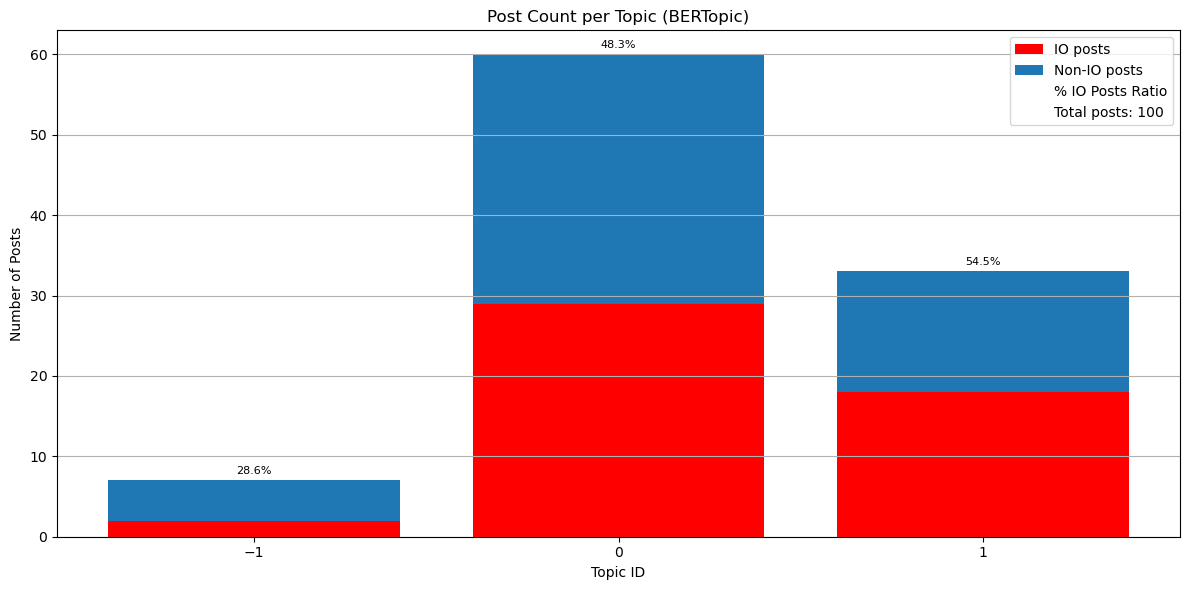

In [95]:
topic_col_name = "BERTopic_topic"
BERT_topic_stats = make_topic_stats(df, topic_col_name)
plot_topic_stats(BERT_topic_stats, topic_col_name, "BERTopic", output_folder_path)

author_io_tag,BERTopic_topic,control_accounts,io_accounts,total_accounts,io_percent
0,-1,5,2,7,28.571429
1,0,31,25,56,44.642857
2,1,15,16,31,51.612903


Plot saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_all/2025_12_23/BERTopic_topic_accounts.png


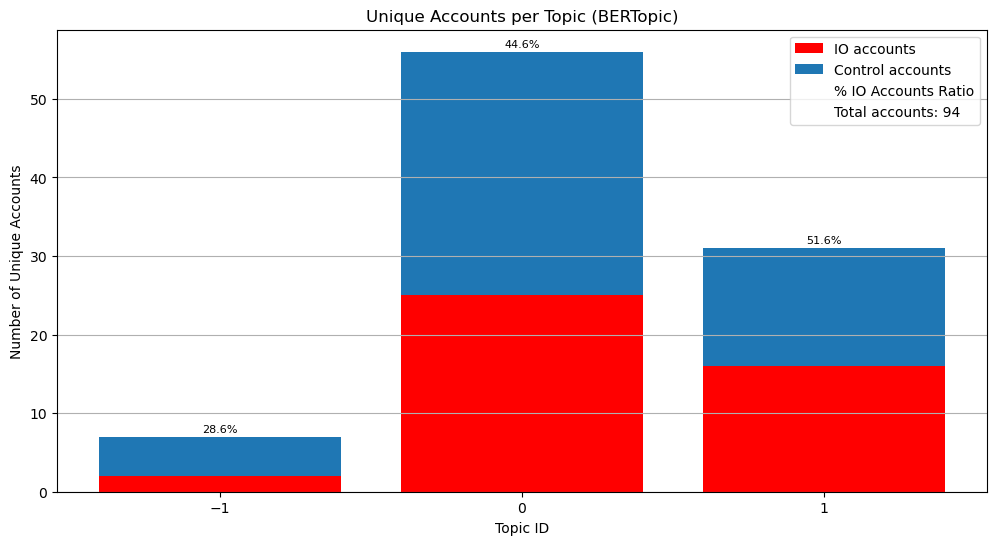

In [96]:
topic_col_name = "BERTopic_topic"

topic_account_stats = make_topic_account_stats(df, topic_col_name)
display(topic_account_stats)
plot_topic_account_stats(topic_account_stats, topic_col_name, "BERTopic", output_folder_path)

In [97]:
try:
    fig = BERTopic_model.visualize_topics(custom_labels=True)
    display(fig)   # show it
except Exception as e:
    print("Not enough topics for visualization")
    print("Error:", e)

Not enough topics for visualization
Error: zero-size array to reduction operation maximum which has no identity


## K-Means

In [98]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def auto_kmeans_topics(embeddings, k_min=30, k_max=200, step = 4):
    best_k = None
    best_score = -1
    best_labels = None

    for k in range(k_min, k_max + 1, step):
        print(f"Trying k={k}")
        km = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels = km.fit_predict(embeddings)
        score = silhouette_score(embeddings, labels)

        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

    return best_labels, best_k

In [99]:
import math

n = len(df)

k_min = max(3, int(math.log(n)))
k_max = min(200 ,int(math.sqrt(n)))

labels, best_k = auto_kmeans_topics(embeddings, k_min=k_min, k_max=k_max)
df["K_Means_topic"] = labels
print(f"\nBest k: {best_k}")
df.head()
df["K_Means_topic"] = labels
print(f"\nBest k: {best_k}")
df.head()

Trying k=4
Trying k=8

Best k: 4

Best k: 4


,postid,post_text,application_name,post_language,in_reply_to_postid,in_reply_to_accountid,post_time,accountid,account_profile_description,follower_count,...,hashtags,urls,account_mentions,is_control,clean_text_with_entities,clean_text_without_enteties,translated_post,BERTopic_topic,BERTopic_prob,K_Means_topic
769276,ca06f1aebbcaf871492fefb92090d0e2e3885dc5be,https://9b6e9a57746724dd79b953b2f0022721b53c58ff26 Con @81442ccfa9f28b934ccf2bb3fb28ebc31af98d0c7d los Jóvenes tienen un futuro lleno de oportunidades🙋‍♀️🙋🏻‍♂️ vamos @2fcc776a3b97d7bc33b3d72acfdf9e9a9f7d55fa3e #MeadeConLosJovenes\n #AvanzarConLosJovenes,15592fcc82d5064a8f4a3b89774e6cd0bbd2118aa0,spa_Latn,None,None,2018-06-06 23:58:11,b28a77b846f3964b7ef4a4134d662fb91726fb0f68,2 de octubre no se olvida. De sandía es mi corazón.,659,...,"[MeadeConLosJovenes, AvanzarConLosJovenes]",[https://9b6e9a57746724dd79b953b2f0022721b53c58ff26],"[71a93e64fa7516b0e2a537a0f7a48c7bd6be6c5ac0, 81442ccfa9f28b934ccf2bb3fb28ebc31af98d0c7d, 2fcc776a3b97d7bc33b3d72acfdf9e9a9f7d55fa3e]",True,url_9b6e9a57746724dd79b953b2f0022721b53c58ff26 con mention_81442ccfa9f28b934ccf2bb3fb28ebc31af98d0c7d los jóvenes tienen un futuro lleno de oportunidades emoji_woman_raising_hand emoji_man_raising_hand_light_skin_tone vamos mention_2fcc776a3b97d7bc33b3d72acfdf9e9a9f7d55fa3e hashtag_meadeconlosjovenes hashtag_avanzarconlosjovenes,<url> con <user> los jóvenes tienen un futuro lleno de oportunidades🙋‍♀️🙋🏻‍♂️ vamos <user> meadeconlosjovenes avanzarconlosjovenes,url_9b6e9a57746724dd79b953b2f0022721b53c58ff26 mention_81442ccfa9f28b934ccf2bb3fb28ebc31af98d0c7d young future full opportunities emoji_woman_raising_hand emoji_man_raising_hand_light_skin_tone let's mention_2fcc776a3b97d7bc33b3d72acfdf9e9a9f7d55fa3e hashtag_meadeconlosovenes htag_avanceconlosovenes,0,0.895073,2
860817,a90d3a1fd06ad7f5ad561d59d54c6602b653e77205,"#VIDEO Chávez: Nuestro camino no es el odio ni la guerra, es el del triunfo y la victoria... La paz con dignidad @25b3f1d6608019c52d8b94a379f8e68619298017fe https://486eba79e2b3d1f820cc0a91920ef1d2ba6c921c82",62010408238d4a0f958ec97eec3db0a4f69bcd0d11,spa_Latn,None,None,2018-08-05 23:48:18,b0afd37c06c5e6cfe04f6c50d5c6d3970a56db8a8b,"Joven Chavista y Revolucionario, Soñador de una Patria Libre y Soberana.\n#ModoActivo por mi Patria.... 💛💙❤️¡Venceremos!",2906,...,[VIDEO],[https://486eba79e2b3d1f820cc0a91920ef1d2ba6c921c82],"[65652740c7b667c0721a0da49b1b1b9622f92debc3, 25b3f1d6608019c52d8b94a379f8e68619298017fe]",True,"hashtag_video chávez: nuestro camino es el odio ni la guerra, es el del triunfo la victoria... la paz con dignidad mention_25b3f1d6608019c52d8b94a379f8e68619298017fe url_486eba79e2b3d1f820cc0a91920ef1d2ba6c921c82","video chávez: nuestro camino es el odio ni la guerra, es el del triunfo la victoria... la paz con dignidad <user> <url>","hashtag_video chavez: path hatred war, triumph victory... peace dignity mention_25b3f1d6608019c52d8b94a379f8e68619298017fe url_486eba79e2b3d1f820cc0a91920ef1d2ba6c921c82",0,0.708825,2
167907,fe6d263080973f8a0473f539bf970935b5d6b45e18,Infidelidad masculina luego del consumo de alcohol podría tener una explicación biológica https://d7a745c4cdf26c5daf1d9379ac376329a55710e137 #EsElColmo,e3415c9cb59e8c2e081aab325f8e78eeef650d5b4b,spa_Latn,None,None,2014-04-14 17:59:00,71cc57155d061d447c2c65756c7dfd6873e403a097,🍃🧚‍♀️🧜‍♀️👑,3618,...,[EsElColmo],[https://d7a745c4cdf26c5daf1d9379ac376329a55710e137],[],False,infidelidad masculina luego del consumo de alcohol podría tener una explicación biológica url_d7a745c4cdf26c5daf1d9379ac376329a55710e137 hashtag_eselcolmo,infidelidad masculina luego del consumo de alcohol podría tener una explicación biológica <url> eselcolmo,male infidelity following alcohol consumption biological explanation url_d7a745c4cdf26c5daf1d9379ac376329a55710e137 hashtag_eselcolmo,0,0.708825,2
395024,d3a1a0c4579b70c4bd1bb82dde38200ddaf5a953ef,"Buenas tardes! Previo a la reinstalación de Audiencia Pública de Escrutinios, Pleno del @8cd86abc87eb6d2e2c121

plot is saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_all/2025_12_23/K-Means_topic_clustering.png


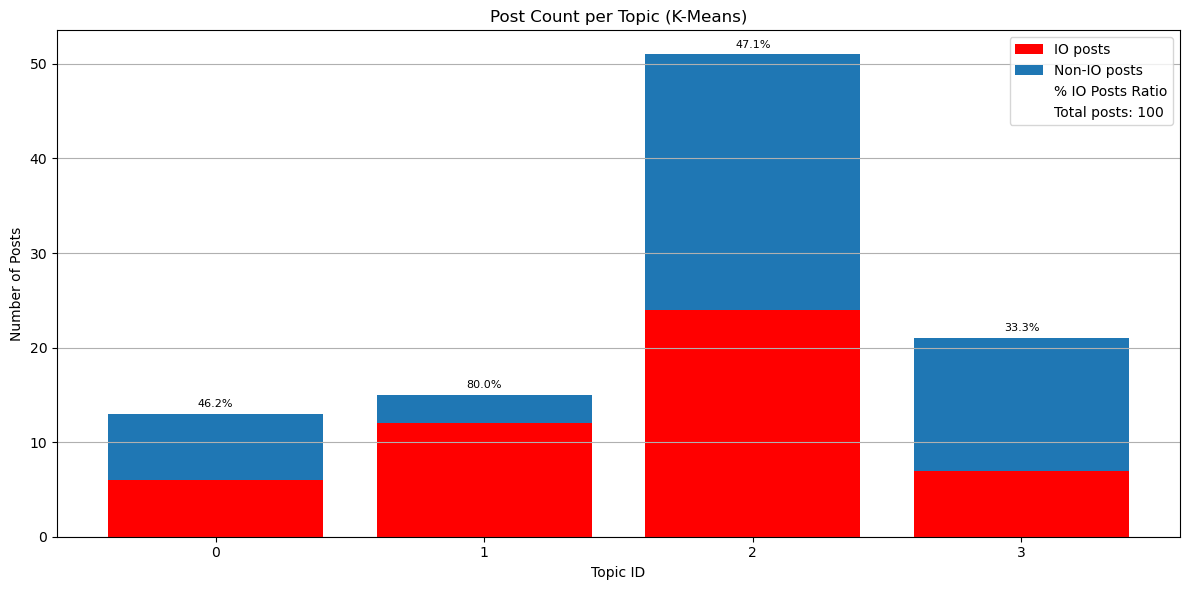

In [100]:
topic_col_name = "K_Means_topic"
topic_stats = make_topic_stats(df, topic_col_name)
plot_topic_stats(topic_stats, topic_col_name, "K-Means", output_folder_path)

author_io_tag,K_Means_topic,control_accounts,io_accounts,total_accounts,io_percent
0,0,7,6,13,46.153846
1,1,3,11,14,78.571429
2,2,27,22,49,44.897959
3,3,14,7,21,33.333333


Plot saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_all/2025_12_23/K_Means_topic_accounts.png


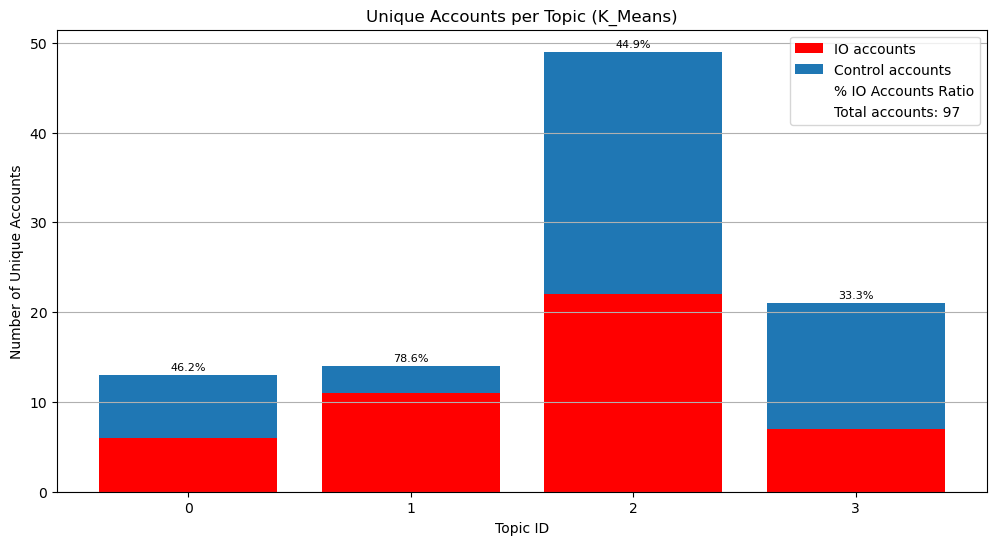

In [101]:
topic_col_name = "K_Means_topic"

topic_account_stats = make_topic_account_stats(df, topic_col_name)
display(topic_account_stats)
plot_topic_account_stats(topic_account_stats, topic_col_name, "K_Means", output_folder_path)

# Named Entity Recognition

In [102]:
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

# Load model ONCE
tokenizer = AutoTokenizer.from_pretrained("TweebankNLP/bertweet-tb2_wnut17-ner")
ner_model = AutoModelForTokenClassification.from_pretrained("TweebankNLP/bertweet-tb2_wnut17-ner")

ner_pipeline = pipeline(
    "token-classification",
    model=ner_model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)


def extract_ner_entities(posts_lst: list):
    """
    Runs NER in batches on a list of text posts.

    Args:
          posts_lst (list): List of strings (cleaned posts).
    Returns
    -------
    all_entities (list[list[str]]): For each post: a list of extracted entity words.
    """

    ner_outputs = ner_pipeline(posts_lst)
    all_entities = []
    for post_output in ner_outputs:
        words = [ent["word"] for ent in post_output]
        all_entities.append(words)

    return all_entities

Device set to use cuda:0


In [103]:
# Apply ONCE, no pandas apply, in order to utilize batches.
df["ner_entities"] = extract_ner_entities(df["translated_post"].to_list())

In [104]:
# display post with ner entities
df.loc[df["ner_entities"].astype(bool), ["post_text", "translated_post", "ner_entities"]].head()

,post_text,translated_post,ner_entities
710506,"#3bb1a651896e919384f4fd7c1a9464e09f8f41f6fa | Fiscal #CarlosBacaM compareció ante la Comisión de Fiscalización de la Asamblea, dentro del proceso de juicio político en su contra. Cuestionó que se solicite a un juicio por hechos que no tienen vinculación con un presunto incumplimiento de sus funciones▼ https://a574382865fc9d34ccb1613ae85e2f510fc89b45c7","hashtag_3bb1a651896e919384f4fd7c1a9464e09f8f41f6fa ♬ prosecutor hashtag_carlosbacam appeared committee inspection assembly, within process impeachment him.",[losbacam]
409973,"En resumen, Estados exigen a Vzla que tome acciones concretas para retornar a la democracia, y ya no aceptan llamados genéricos al diálogo","short, states demand vzla take concrete action return democracy, longer accept generic calls dialogue.","[v@@, zla]"
337359,Centro Democrático no asistió al encuentro convocado por Santos https://d9155741dd04ea4ed2e529af1e99c20257591c18a0 vía @decb7ac830226daea81f865774d3814746a6f72dd9,democratic centre attend meeting convened saints url_d9155741dd04ea4ed2e529af1e99c20257591c18a0 via mention_decb7ac830226daea81f865774d3814746a6f72dd9,[democratic centre]
334335,#ÚLTIMAHORA | 17 miembros de la Ejecutiva del #PSOE dimiten para acabar con Pedro Sánchez y detener un acuerdo con #Podemos en #España https://bdcd0bf93bb95d8f09a1aee92f6e4aee24f67816cb,17 members executive board hashtag_psoe resign end pedro sanchez stop deal hashtag_we hashtag_spanish url_bdcd0bf93bb95d8f09a1aee92f6e4aee24f67816cb,"[pso@@, pedro sanchez]"
605979,"En reuniones bilaterales con @08d931d0160470e822c035861dbfa8bb15322eee5b @3b8529ff2698452cc65dc57fe35380bb3833769aa2 y @013e16d6dfcb5b22d655f4ef0da77f04605f18dbde en @bebc6e11ab5139fd73a7278f28b641bc8979dad50e abordamos sobre el proceso político ecuatoriano, nuestro programa de gobierno y reformas al sistema de NNUU así como la candidatura propuesta de #Ecuador para @1e6f8471c09745f4c5672f1bbd4c1f57959514d536 https://daee4fb2e435eedca63498946804d82dde44106c8f","bilateral meetings mention_08d931d0160470e822c035861dbfa8bb15322eee5b mention_3b8529ff2698452cc65dc57fe35380bb3833769aa2 mention_013e16d6dfcb5b22d655f4ef0da77f04605f18dbde mention_bebc6e11ab5139fd73a7278f28b641b641bc897950e ecuadorian political process, government programme reforms nn system well candidacy huetag_ecuador mention_1d6e4e4e4e4e4e4e4e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e5e","[ec@@, uadorian]"


# Clean Entities

In [105]:
def clean_entity_columns(df, entity_cols_lst):
    """Normalize entity columns to match TfidfVectorizer behavior.

    Converts each entity to a stripped, lowercase string for all columns
    listed in ``entity_cols_lst``.
    The function modifies ``df``.

    Args:
        df: Input DataFrame.
        entity_cols_lst: Columns containing lists of entities.

    Returns:
        None.
    """
    for col in entity_cols_lst:
        df[col] = df[col].apply(lambda lst: [str(e).strip().lower().replace(" ", "_") for e in lst])

In [106]:
entity_cols_lst = ["hashtags", "account_mentions", "urls", "ner_entities"]
clean_entity_columns(df, entity_cols_lst)

# Entities Statistics

In [107]:
def entity_topic_counts(
    df: pd.DataFrame,
    entity_col: str,
    topic_col: str,
) -> pd.DataFrame:
    """Return entity-topic count matrix.

    Args:
        df: Input DataFrame.
        entity_col: Column with entity IDs (list-like).
        topic_col: Column with topic labels.

    Returns:
        DataFrame with entities as index, topics as columns, counts as values.
    """
    
    df_exploded = (
        df[[entity_col, topic_col]]
        .explode(entity_col)
        .dropna(subset=[entity_col, topic_col])
    )

    return pd.crosstab(
        index=df_exploded[entity_col],
        columns=df_exploded[topic_col],
        dropna=False,
    )


In [108]:
def plot_entity_topic_counts(
    entity,
    entity_topic_counts,
    clustering_model: str = "",
    output_folder_path=None,
):
    """Plot how many times a given entity appears in each topic.

    Args:
        entity: Entity ID that exists in entity_topic_counts.index.
        entity_topic_counts: DataFrame from pd.crosstab (index=entity, columns=topic, values=counts).
        clustering_model: Optional label to annotate the plot.
        output_folder_path: If given (Path-like), saves PNG to this folder.
    """
    # Extract row for chosen entity (entity is in the index)
    counts = entity_topic_counts.loc[entity]  # Series: topic_id -> count

    # Topic columns
    topic_cols = list(entity_topic_counts.columns)


    # --- Plot ---
    plt.figure(figsize=(12, 5))
    plt.bar(topic_cols, counts.values)

    plt.title(f"Topic Distribution for Entity: '{entity}'")
    plt.xlabel("Topic ID")
    plt.ylabel("Count of occurrences")
    plt.xticks(topic_cols)
    plt.grid(axis="y")

    # Metadata note (top-right)
    plt.text(
        0.98, 0.92,
        f"clustering model: {clustering_model}",
        ha="right",
        va="top",
        transform=plt.gca().transAxes
    )

    plt.tight_layout()

    # Save if path provided
    if output_folder_path is not None:
        plot_path = output_folder_path / f"{entity}_topic_distribution.png"
        plt.savefig(plot_path, dpi=300)
        print(f"Saved figure to: {plot_path}")

    plt.show()
    plt.close()

BERTopic_topic,-1,0,1
ner_entities,,,
ade@@,0,1,0
adrian,0,1,0
alarcon,0,1,0
andro@@,0,1,0
anzo@@,0,0,1


Saved figure to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_all/2025_12_23/ade@@_topic_distribution.png


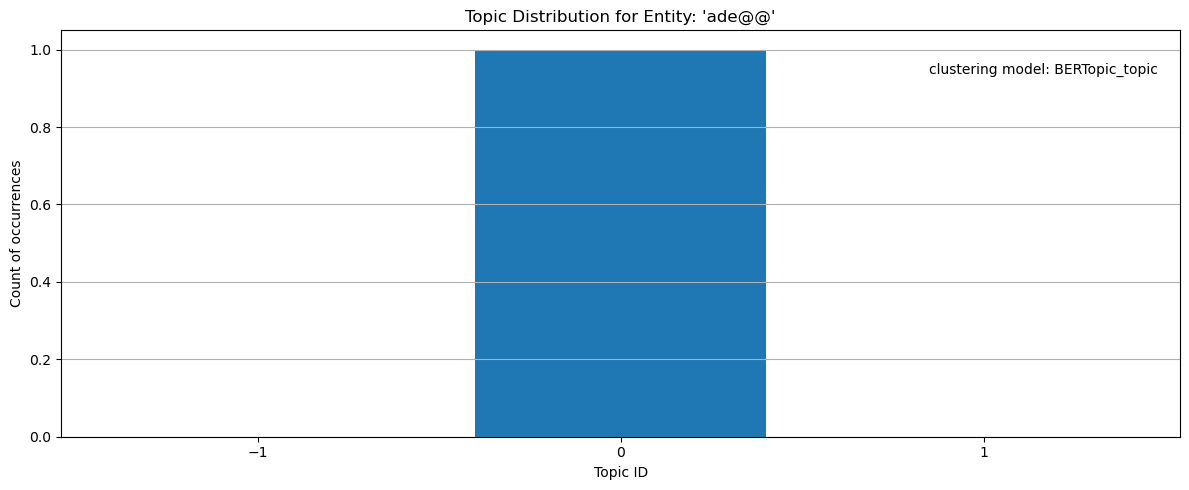

In [109]:
entity_col_name = "ner_entities"
topic_col = "BERTopic_topic"

entity_topic_counts_df = entity_topic_counts(df, entity_col_name, topic_col)
display(entity_topic_counts_df.head())

entity = entity_topic_counts_df.index[0]   # first entity
plot_entity_topic_counts(entity=entity, entity_topic_counts=entity_topic_counts_df, clustering_model=topic_col, output_folder_path=output_folder_path)

# Save to parquet

In [110]:
# print dataset statistics
for col in df.columns:
    sample_val = df[col].dropna().iloc[0] if df[col].notna().any() else None
    print(f"{col:<30} | {type(sample_val).__name__}")

postid                         | str
post_text                      | str
application_name               | str
post_language                  | str
in_reply_to_postid             | str
in_reply_to_accountid          | str
post_time                      | Timestamp
accountid                      | str
account_profile_description    | str
follower_count                 | int64
following_count                | int64
account_creation_date          | date
is_repost                      | bool
reposted_accountid             | str
reposted_postid                | str
hashtags                       | list
urls                           | list
account_mentions               | list
is_control                     | bool
clean_text_with_entities       | str
clean_text_without_enteties    | str
translated_post                | str
BERTopic_topic                 | int64
BERTopic_prob                  | float64
K_Means_topic                  | int32
ner_entities                   | list


In [111]:
df_output_path = output_folder_path / f"Topic_Ner_{file_name}"

df.to_parquet(df_output_path, index=False, compression="gzip")
print("df is saved to:", df_output_path)

df is saved to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_all/2025_12_23/Topic_Ner_Ecuador_part_all.gzip.parquet
